### Descargamos las librerias necesarias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Ahora cargo el documento csv

In [2]:
df= pd.read_csv('amz_uk_price_prediction_dataset.csv')

### Exploramos el Dataset.

In [3]:
df.head()
print(df.shape)
df.info()
df.describe()

(2443651, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


### Observaciones del Dataset:
- Hay 2.443.651 filas
- El precio máx es 100.000£ y el mínomo es 0£, algo muy raro para ser Amazon
- "Stars" debería de llamarse "Rating", y tiene mín. de 0, así que podemos decir que hay productos sin valoración.

### Ahora hacemos limpieza de datos

In [4]:
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

No hay ningún valor nulo.

In [5]:
df.duplicated().sum()

np.int64(0)

Tampoco hay duplicados

###Sacamos las tablas de frecuencia

In [6]:
df['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

### Observaciones:
- "Sports & Outdoors" tiene 836.265 productos
- La segunda categoría "Beauty" sitene 19.312 productos.

In [7]:
df['category'].value_counts(normalize=True)

category
Sports & Outdoors                         0.342219
Beauty                                    0.007903
Handmade Clothing, Shoes & Accessories    0.007869
Bath & Body                               0.007813
Birthday Gifts                            0.007766
                                            ...   
Alexa Built-In Devices                    0.000044
Motorbike Chassis                         0.000044
Plugs                                     0.000044
Smart Home Security & Lighting            0.000043
Smart Speakers                            0.000022
Name: proportion, Length: 296, dtype: float64

### Observaciones:
- "Sports & Outdoors" representa el 34% de todos los productos
- El resto de categorías no llegan al 1%
- No podemos hacer un gráfico porque hay 196 categorías y sería ilegible (El enunciado avisa que hay que hacer subconjunto con las top categorías)

In [8]:
#Guardamos las top 10 en una variable
top10 = df['category'].value_counts().head(10)

C:\Users\erika\AppData\Local\Temp\ipykernel_6092\3885321382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index, y=top10.values, palette="Set3") #Agrego esta línea para que los nombres no se superpongan


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sports & Outdoors'),
  Text(1, 0, 'Beauty'),
  Text(2, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(3, 0, 'Bath & Body'),
  Text(4, 0, 'Birthday Gifts'),
  Text(5, 0, 'Manicure & Pedicure Products'),
  Text(6, 0, 'Skin Care'),
  Text(7, 0, 'Make-up'),
  Text(8, 0, 'Hair Care'),
  Text(9, 0, 'Fragrances')])

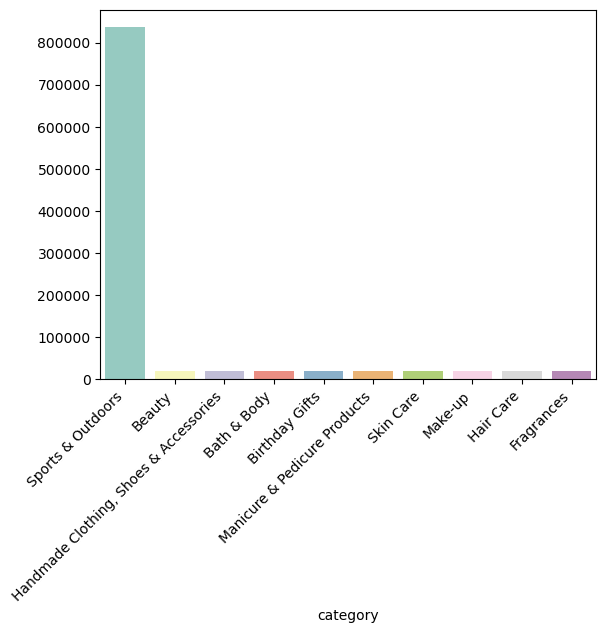

In [9]:
# Hacemos barplot porque  las variables son numéricas.
sns.barplot(x=top10.index, y=top10.values, palette="Set3") #Agrego esta línea para que los nombres no se superpongan
plt.xticks(rotation=45, ha='right')

### Observaciones:
- "Sports&Outdoors" es la categoría que más destaaca
- Considero que a pesar de que el resto de las categorías están parecidas, los datos no están muy equilibrados.

<Axes: ylabel='count'>

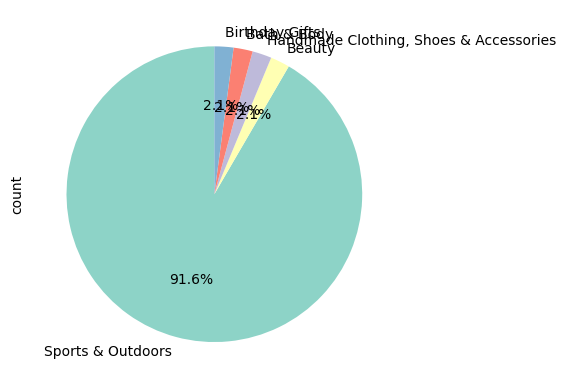

In [10]:
top5 = df['category'].value_counts().head(5)
top5.plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))

### Observaciones:
- "Sports&Outdoors" domina el gráfico de nuevo con un 91,6%
- Se puede ver que si hay una categoría que ocupa mucho, y luego hay muchos datos, es muy difícil ver las diferencias entre las categorías que son más pequeñas.

In [11]:
df['price'].describe()
print(df['price'].mean())
print(df['price'].median())
print(df['price'].mode()[0])

89.24380943923661
19.09
9.99


### Observaciones:
- La media (89£) es mucho mas alta que la mediana (19£).
- Eso quiere decir que hay productos muy caros que están tirando la media hacia arriba.

In [14]:
print(df['price'].var())
print(df['price'].std())
print(df['price'].min())
print(df['price'].max())
range_price = df['price'].max() - df['price'].min()
print(range_price)


119445.48532256528
345.60886175352226
0.0
100000.0
100000.0


### Observaciones:
- La varianza es 119.445, que es muy alta y nos dice que los precios están muy dispersos
- Desviación estándar es 345£ esto nos indica que se desvía muchisimo de la media que era 89£
- El míno es cero, que no tiene sentido, porque eso significaría que hay productos sin valor, son gratis¿?
- El máximo 100.000£, que siginificaría que son productos extremadamente caros
- El rango tiene también 100.000£, esto nos dice que hay una diferencias muy grande entre el producto más barato, y el más caro

### Hacemos el IQR:

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

36.0


### Observaciones:
- El IQR es de 36, eso nos indica que el 50% central de los productos tiene precios entre Q1 y Q3, con una diferencia de solo 36£.
- Esto no dice que contrasta mucho con el rango, y nos dice que los precios  extremos son outliers que distorsionan la distribución.

### Creamos el histograma y el box plot del precio

<Axes: xlabel='price', ylabel='Count'>

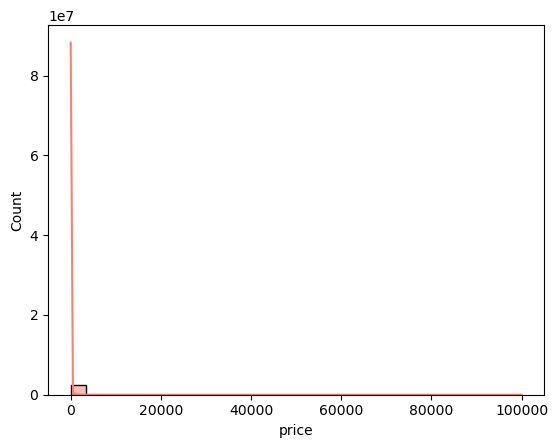

In [16]:
sns.histplot(df['price'], kde=True, bins=30, color="salmon")

### Obervaciones:
- Los outliers aplastan el gráfico y no dejan ver donde están el resto de datos
- La solución sería filtrar los datos y quedarnos con los precios más comunes, o limitar hasta un determinado importe

<Axes: xlabel='price', ylabel='Count'>

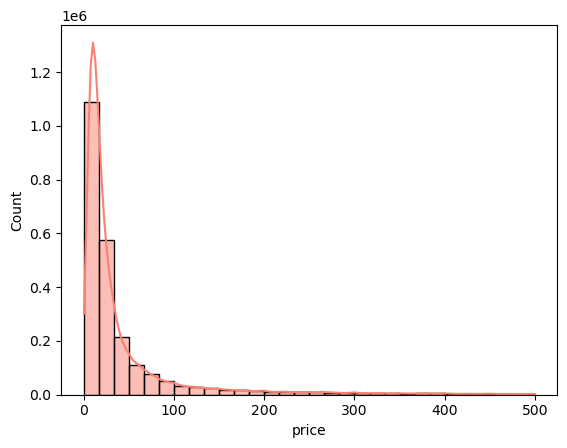

In [17]:
sns.histplot(df[df['price'] < 500]['price'], kde=True, bins=30, color="salmon")

### Observaciones:
- Ahora se ven los datos mejor.
- La distribución de la cola es larga hacia la derecha (sesgo positivo)
- Hay pocos productos entre 100 y 500 libras

<Axes: ylabel='price'>

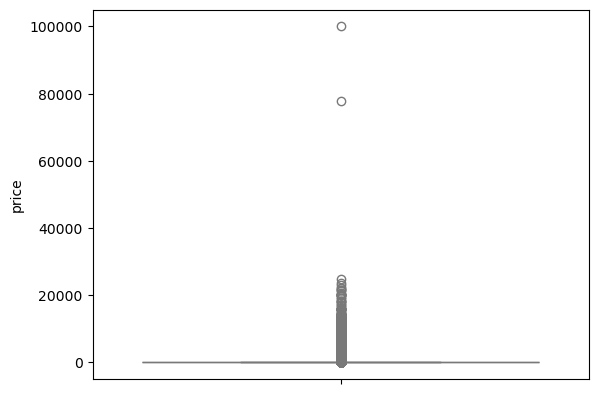

In [19]:
sns.boxplot(data=df['price'], color="lightblue")

### Observaciones:
- La caja es invisible porque está abajo del todo, supongo que es porque el 50% central de los productos son muy baratos
- Hay muchisimos outliers representados por los puntos con precios muy altos.
- Quizás filtrando se vería mejor

<Axes: ylabel='price'>

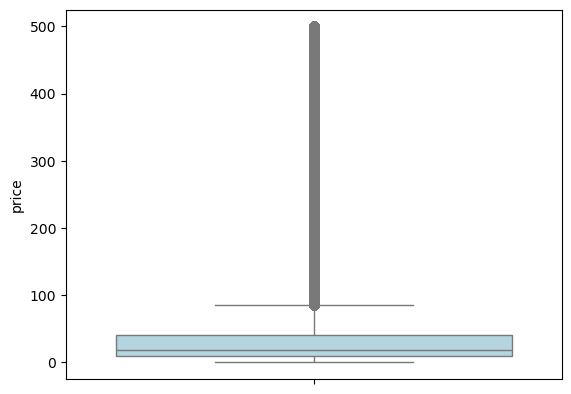

In [20]:
sns.boxplot(data=df[df['price'] < 500]['price'], color="lightblue")

### Observaciones:
- La cajar está entre el 0 y el 50 aprox, muy comprimida hacia abajo
- La mediana está alrededor de 19, lo que hace que coincida con lo calculado antes
- El bigote superior llega hasta las 90 libras.
- Los outliers son productos entre 90 y 500

### Ahora haremos los products ratnings

In [21]:
df['stars'].describe()
print(df['stars'].mean())
print(df['stars'].median())
print(df['stars'].mode()[0])

2.152836472966066
0.0
0.0


### Observaciones:
- La media es de 2,15 estrellas de valoración
- La media y la moda es de 0.0, lo que significa que la mayoría de productos no tienen valoración

In [23]:
print(df['stars'].var())
print(df['stars'].std())
Q1 = df['stars'].quantile(0.25)
Q3 = df['stars'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

4.81743402976196
2.1948653785054697
4.4


### Observaciones:
- La varianza es de 4.82, bastante alta para una escala del 0 al 5
- La desviación estándar es de 2.19,  lo que nos dice que los productos se desvían de media 2 estrellas respecto la media
- El IQR es 4.4, es decir, el 60% central de todos los productos tiene una diferencia de 4.4 estrellas, casi igual que toda la escala
- Todo esto nos dice que hay muchisima variación en las valoraciones, porque tienen muchos productos tienen 0 estrellas

In [25]:
print(df['stars'].skew())
print(df['stars'].kurtosis())

0.08120735761080881
-1.9260061280432994


### Observaciones:
- Skewness es 0.08, casi 0, lo que significa que la distribución es casi simétrica
- Kurtosis es -1.93,  lo que siginifica que la distribución es más plana de lo normal y tiene menos outliers de los esperados

<Axes: xlabel='stars', ylabel='Count'>

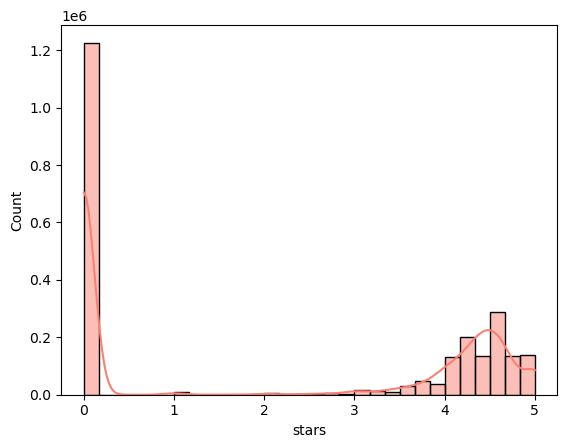

In [26]:
sns.histplot(df['stars'], kde=True, bins=30, color="salmon")

### Obervaciones:
- Hay un pico en 0 estrellas, lo que nos remarca los productos sin valoración
- No hay casi nada entre 1 y 3 estrellas
- Y otro grupo grande entre 4 y5 estrellas, esto nos dice, que los productos que si tienen puntuación, tienen puntuaciones altas